## AutoML Notebook
Tyrese Rome Tan-Gatue, *Aspiring Data Scientist*

In [43]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

## Regression

In [74]:
def regress(
    X,
    y,
    numeric_features,
    categorical_features=None,
    model_name="linear",
    split_strategy="train_test",
    test_size=0.25,
    val_size=0.25,
    n_splits=5,
    n_repeats=30,
    neighbor_range=range(1,15),
    random_state=0
):
    y = np.ravel(y)
    if categorical_features is None:
        categorical_features = []

    # ------------------------
    # Preprocessing
    # ------------------------
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    # ------------------------
    # Model selection
    # ------------------------
    if model_name == "linear":
        model = LinearRegression()
    elif model_name == "ridge":
        model = Ridge()
    elif model_name == "lasso":
        model = Lasso()
    elif model_name == "knn":
        # Monte Carlo KNN will override standard CV
        if split_strategy != "monte_carlo":
            model = KNeighborsRegressor()
    else:
        raise ValueError("Invalid model_name")

    # ------------------------
    # Monte Carlo KNN
    # ------------------------
    if model_name == "knn" and split_strategy == "monte_carlo":
        training_acc = pd.DataFrame()
        test_acc = pd.DataFrame()
        for seed in range(random_state, random_state + n_repeats):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )
            train_scores = []
            test_scores = []
            for k in neighbor_range:
                reg = KNeighborsRegressor(n_neighbors=k)
                reg.fit(X_train, y_train)
                train_scores.append(reg.score(X_train, y_train))
                test_scores.append(reg.score(X_test, y_test))
            training_acc[seed] = train_scores
            test_acc[seed] = test_scores

        # Plot mean ± standard error
        fig, ax = plt.subplots(figsize=(15,6))
        mean_train = training_acc.mean(axis=1)
        std_train = training_acc.std(axis=1)
        mean_test = test_acc.mean(axis=1)
        std_test = test_acc.std(axis=1)
        ax.plot(neighbor_range, mean_train, label="Training $R^2$", color='blue', marker='o', linestyle='dashed', markersize=12)
        ax.fill_between(neighbor_range, mean_train - std_train/2, mean_train + std_train/2, alpha=0.2, color='blue')
        ax.plot(neighbor_range, mean_test, label="Test $R^2$", color='red', marker='^', linestyle='-', markersize=12)
        ax.fill_between(neighbor_range, mean_test - std_test/2, mean_test + std_test/2, alpha=0.2, color='red')
        ax.set_xlabel("n_neighbors", fontsize=15)
        ax.set_ylabel("$R^2$", fontsize=15)
        ax.set_title("Monte Carlo KNN Regressor Accuracy vs n_neighbors", fontsize=16)
        ax.legend(fontsize=12)
        ax.grid(True)
        plt.show()
        return training_acc, test_acc

    # ------------------------
    # Standard train/test or k-fold for other regressors
    # ------------------------
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    if split_strategy == "train_test":
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        print(f"Test R^2: {r2:.4f} | MSE: {mse:.4f}")
        return pipeline

    elif split_strategy == "train_val_test":
        X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
        val_fraction = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_fraction, random_state=random_state)
        pipeline.fit(X_train, y_train)
        val_pred = pipeline.predict(X_val)
        test_pred = pipeline.predict(X_test)
        print(f"Validation R^2: {r2_score(y_val, val_pred):.4f}")
        print(f"Test R^2: {r2_score(y_test, test_pred):.4f}")
        return pipeline

    elif split_strategy == "k_fold":
        from sklearn.model_selection import cross_val_score
        pipeline.fit(X, y)
        scores = cross_val_score(pipeline, X, y, cv=n_splits, scoring='r2')
        print(f"{n_splits}-Fold CV R^2 scores: {scores}")
        print(f"Mean R^2: {scores.mean():.4f}")
        return pipeline

    else:
        raise ValueError("Invalid split_strategy")

# Classification

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

def classify(
    X,
    y,
    numeric_features,
    categorical_features=None,
    model_name="",
    split_strategy="train_test",
    test_size=0.25,
    val_size=0.25,
    n_splits=5,
    n_repeats=50,
    neighbor_range=range(1,50),
    random_state=42
):
    y = np.ravel(y)
    if categorical_features is None:
        categorical_features = []

    # ------------------------
    # Preprocessing
    # ------------------------
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    # ------------------------
    # Model selection
    # ------------------------
    if model_name == "logistic":
        model = LogisticRegression(max_iter=5000, random_state=random_state)
        param_grid = {'model__C': np.logspace(-3,3,20)}
    elif model_name == "svm":
        model = LinearSVC(max_iter=5000, dual=False, random_state=random_state)
        param_grid = {'model__C': np.logspace(-3,3,20)}
    elif model_name == "knn":
        # Monte Carlo KNN will override standard CV
        if split_strategy != "monte_carlo":
            model = KNeighborsClassifier()
            param_grid = {
                'model__n_neighbors': range(1,31),
                'model__weights': ['uniform','distance']
            }
    else:
        raise ValueError("Invalid model_name")

    # ------------------------
    # Split / CV
    # ------------------------
    if split_strategy == "monte_carlo" and model_name == "knn":
        training_acc = pd.DataFrame()
        test_acc = pd.DataFrame()
        for seed in range(random_state, random_state + n_repeats):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed, stratify=y
            )
            train_scores = []
            test_scores = []
            for k in neighbor_range:
                knn = KNeighborsClassifier(n_neighbors=k)
                knn.fit(X_train, y_train)
                train_scores.append(knn.score(X_train, y_train))
                test_scores.append(knn.score(X_test, y_test))
            training_acc[seed] = train_scores
            test_acc[seed] = test_scores

        plt.figure(figsize=(10,6))
        plt.errorbar(neighbor_range, training_acc.mean(axis=1),
                     yerr=training_acc.std(axis=1)/2, label="Training Accuracy", marker='o')
        plt.errorbar(neighbor_range, test_acc.mean(axis=1),
                     yerr=test_acc.std(axis=1)/6, label="Test Accuracy", marker='s')
        plt.xlabel("n_neighbors")
        plt.ylabel("Accuracy")
        plt.title("Monte Carlo KNN Accuracy vs n_neighbors")
        plt.legend()
        plt.grid(True)
        plt.show()
        return training_acc, test_acc

    # For other strategies or models, fall back to standard GridSearchCV
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    if split_strategy == "train_test":
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        from sklearn.model_selection import GridSearchCV
        search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test)
        print("Best Parameters:", search.best_params_)
        print("CV Best Score:", search.best_score_)
        print("Test Accuracy:", accuracy_score(y_test, y_pred))
        print(classification_report(y_test, y_pred))
        return best_model, search

    elif split_strategy == "train_val_test":
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        val_fraction = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=val_fraction, random_state=random_state, stratify=y_temp
        )
        pipeline.fit(X_train, y_train)
        val_pred = pipeline.predict(X_val)
        test_pred = pipeline.predict(X_test)
        print("Validation Accuracy:", accuracy_score(y_val, val_pred))
        print("Test Accuracy:", accuracy_score(y_test, test_pred))
        return pipeline

    elif split_strategy == "k_fold":
        from sklearn.model_selection import GridSearchCV
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        search.fit(X, y)
        best_model = search.best_estimator_
        print("Best Parameters:", search.best_params_)
        print("CV Best Score:", search.best_score_)
        return best_model, search

    else:
        raise ValueError("Invalid split_strategy")

In [76]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
ds = load_wine()
ds.keys()
df = pd.DataFrame(ds.data,columns = ds.feature_names)
target = ds.target

df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


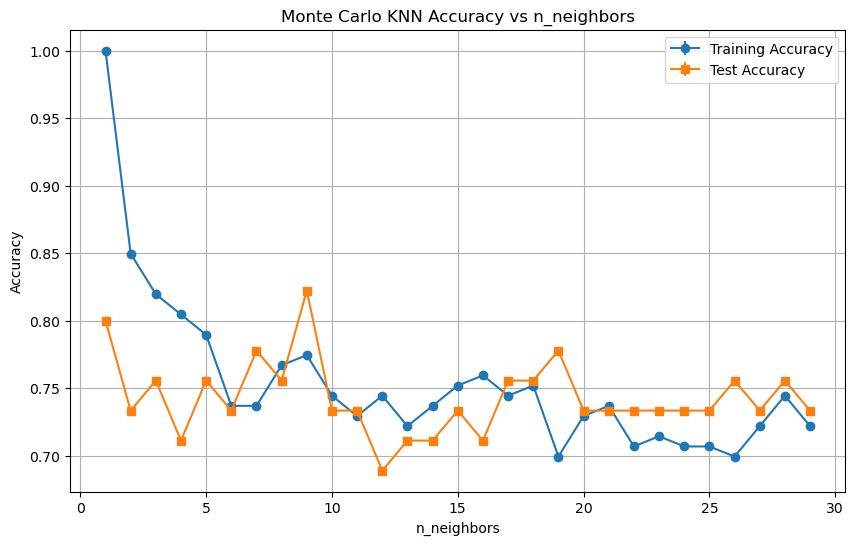

           5
0   0.800000
1   0.733333
2   0.755556
3   0.711111
4   0.755556
5   0.733333
6   0.777778
7   0.755556
8   0.822222
9   0.733333
10  0.733333
11  0.688889
12  0.711111
13  0.711111
14  0.733333
15  0.711111
16  0.755556
17  0.755556
18  0.777778
19  0.733333
20  0.733333
21  0.733333
22  0.733333
23  0.733333
24  0.733333
25  0.755556
26  0.733333
27  0.755556
28  0.733333


In [113]:
train, test = classify(X = df, 
                       y=target,
                       numeric_features = df.columns,
                       model_name = "knn",
                       categorical_features =[],
                       random_state = 5,
                       split_strategy = "monte_carlo",
                       neighbor_range = range(1,30), n_repeats = 1)

print(test)

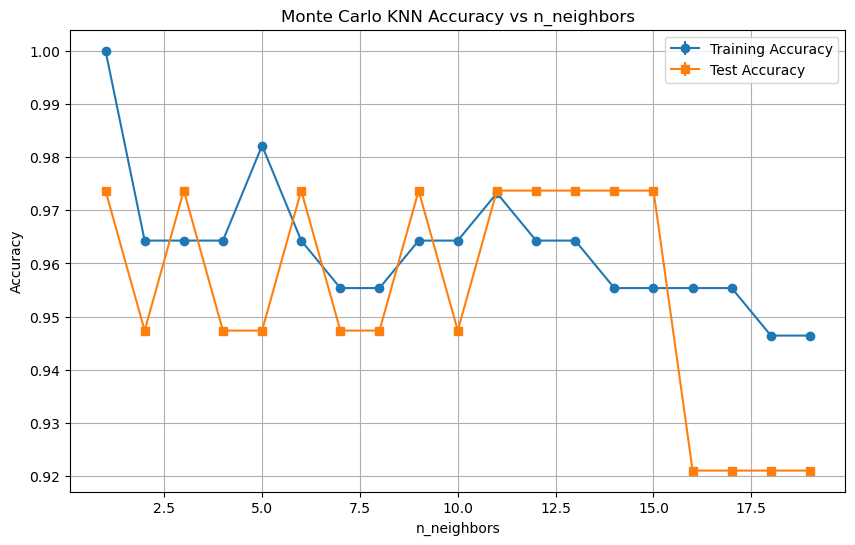

           1
0   0.973684
1   0.947368
2   0.973684
3   0.947368
4   0.947368
5   0.973684
6   0.947368
7   0.947368
8   0.973684
9   0.947368
10  0.973684
11  0.973684
12  0.973684
13  0.973684
14  0.973684
15  0.921053
16  0.921053
17  0.921053
18  0.921053


In [109]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

# Monte Carlo KNN evaluation
training_acc, test_acc = classify(
    X, y,
    numeric_features=iris.feature_names,
    categorical_features=None,
    model_name="knn",
    split_strategy="monte_carlo",
    neighbor_range=range(1,20),
    n_repeats=1,
    random_state=1
)

print(test_acc)

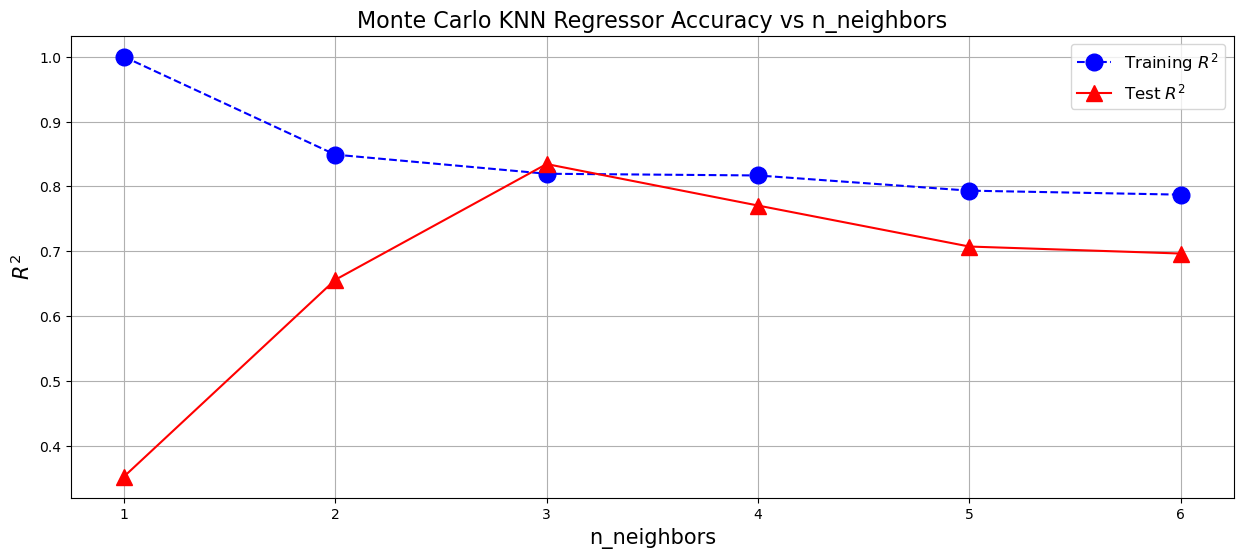

          0
0  1.000000
1  0.848930
2  0.819434
3  0.816801
4  0.793363
5  0.787190
          0
0  0.351987
1  0.655749
2  0.834417
3  0.770419
4  0.707138
5  0.696355


In [91]:
import mglearn
X, y = mglearn.datasets.make_wave(n_samples=40)

# Monte Carlo KNN
training_acc, test_acc = regress(
    X, y,
    numeric_features=[0],  # wave dataset has 1 feature
    model_name='knn',
    split_strategy='monte_carlo',
    neighbor_range=range(1,7),
    n_repeats=1,
    random_state=0
    
)
print(training_acc)
print(test_acc)